In [1]:
!pip install sentence-transformers seaborn

In [2]:
sentences = [
# Cricket
"The batsman scored a century in the final match.",
"The bowler delivered a perfect yorker.",
"The cricket team celebrated their victory after the tournament.",

# Cooking
"The chef prepared a delicious pasta with fresh ingredients.",
"Baking a chocolate cake requires precise measurements.",
"The soup was simmered slowly to enhance the flavor.",

# Cybersecurity
"Strong passwords help protect accounts from hackers.",
"Cybersecurity experts monitor networks for suspicious activity.",
"Phishing attacks try to steal sensitive information from users.",

# Extra sentence (any topic)
"The captain set an aggressive field during the cricket match."
]

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Number of embeddings:", len(embeddings))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Number of embeddings: 10


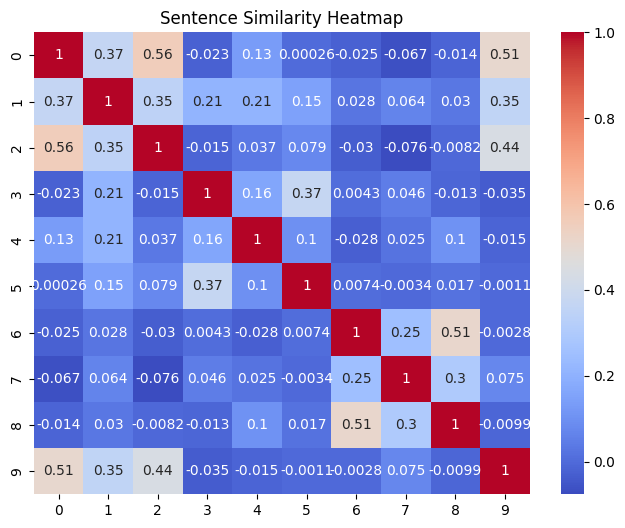

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [5]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

import numpy as np

top_indices = np.argsort(similarities)[-2:][::-1]

print("Query:", query)
print()

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity score:", similarities[i])
    print()

Query: The bowler took three wickets in one over

Sentence: The batsman scored a century in the final match.
Similarity score: 0.5679121

Sentence: The bowler delivered a perfect yorker.
Similarity score: 0.54640985

